In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import stim
import sinter
import matplotlib.pyplot as plt
import os
from qecsim.codes.lattice_surgery.circuit import surgery_circuit
import pickle
import numpy as np
from scipy.optimize import curve_fit
from scipy.optimize import brentq

Adding the Observables manually doesn't really work. Stim therefore has a function called solve_flow_measurements:
<br>
<br>
    -> Implements the observables who satisfy needed flow i.e. X1 -> X1X2 in the normal CX case
<br>
    -> Keeps the corrective CZ/CX gates in mind

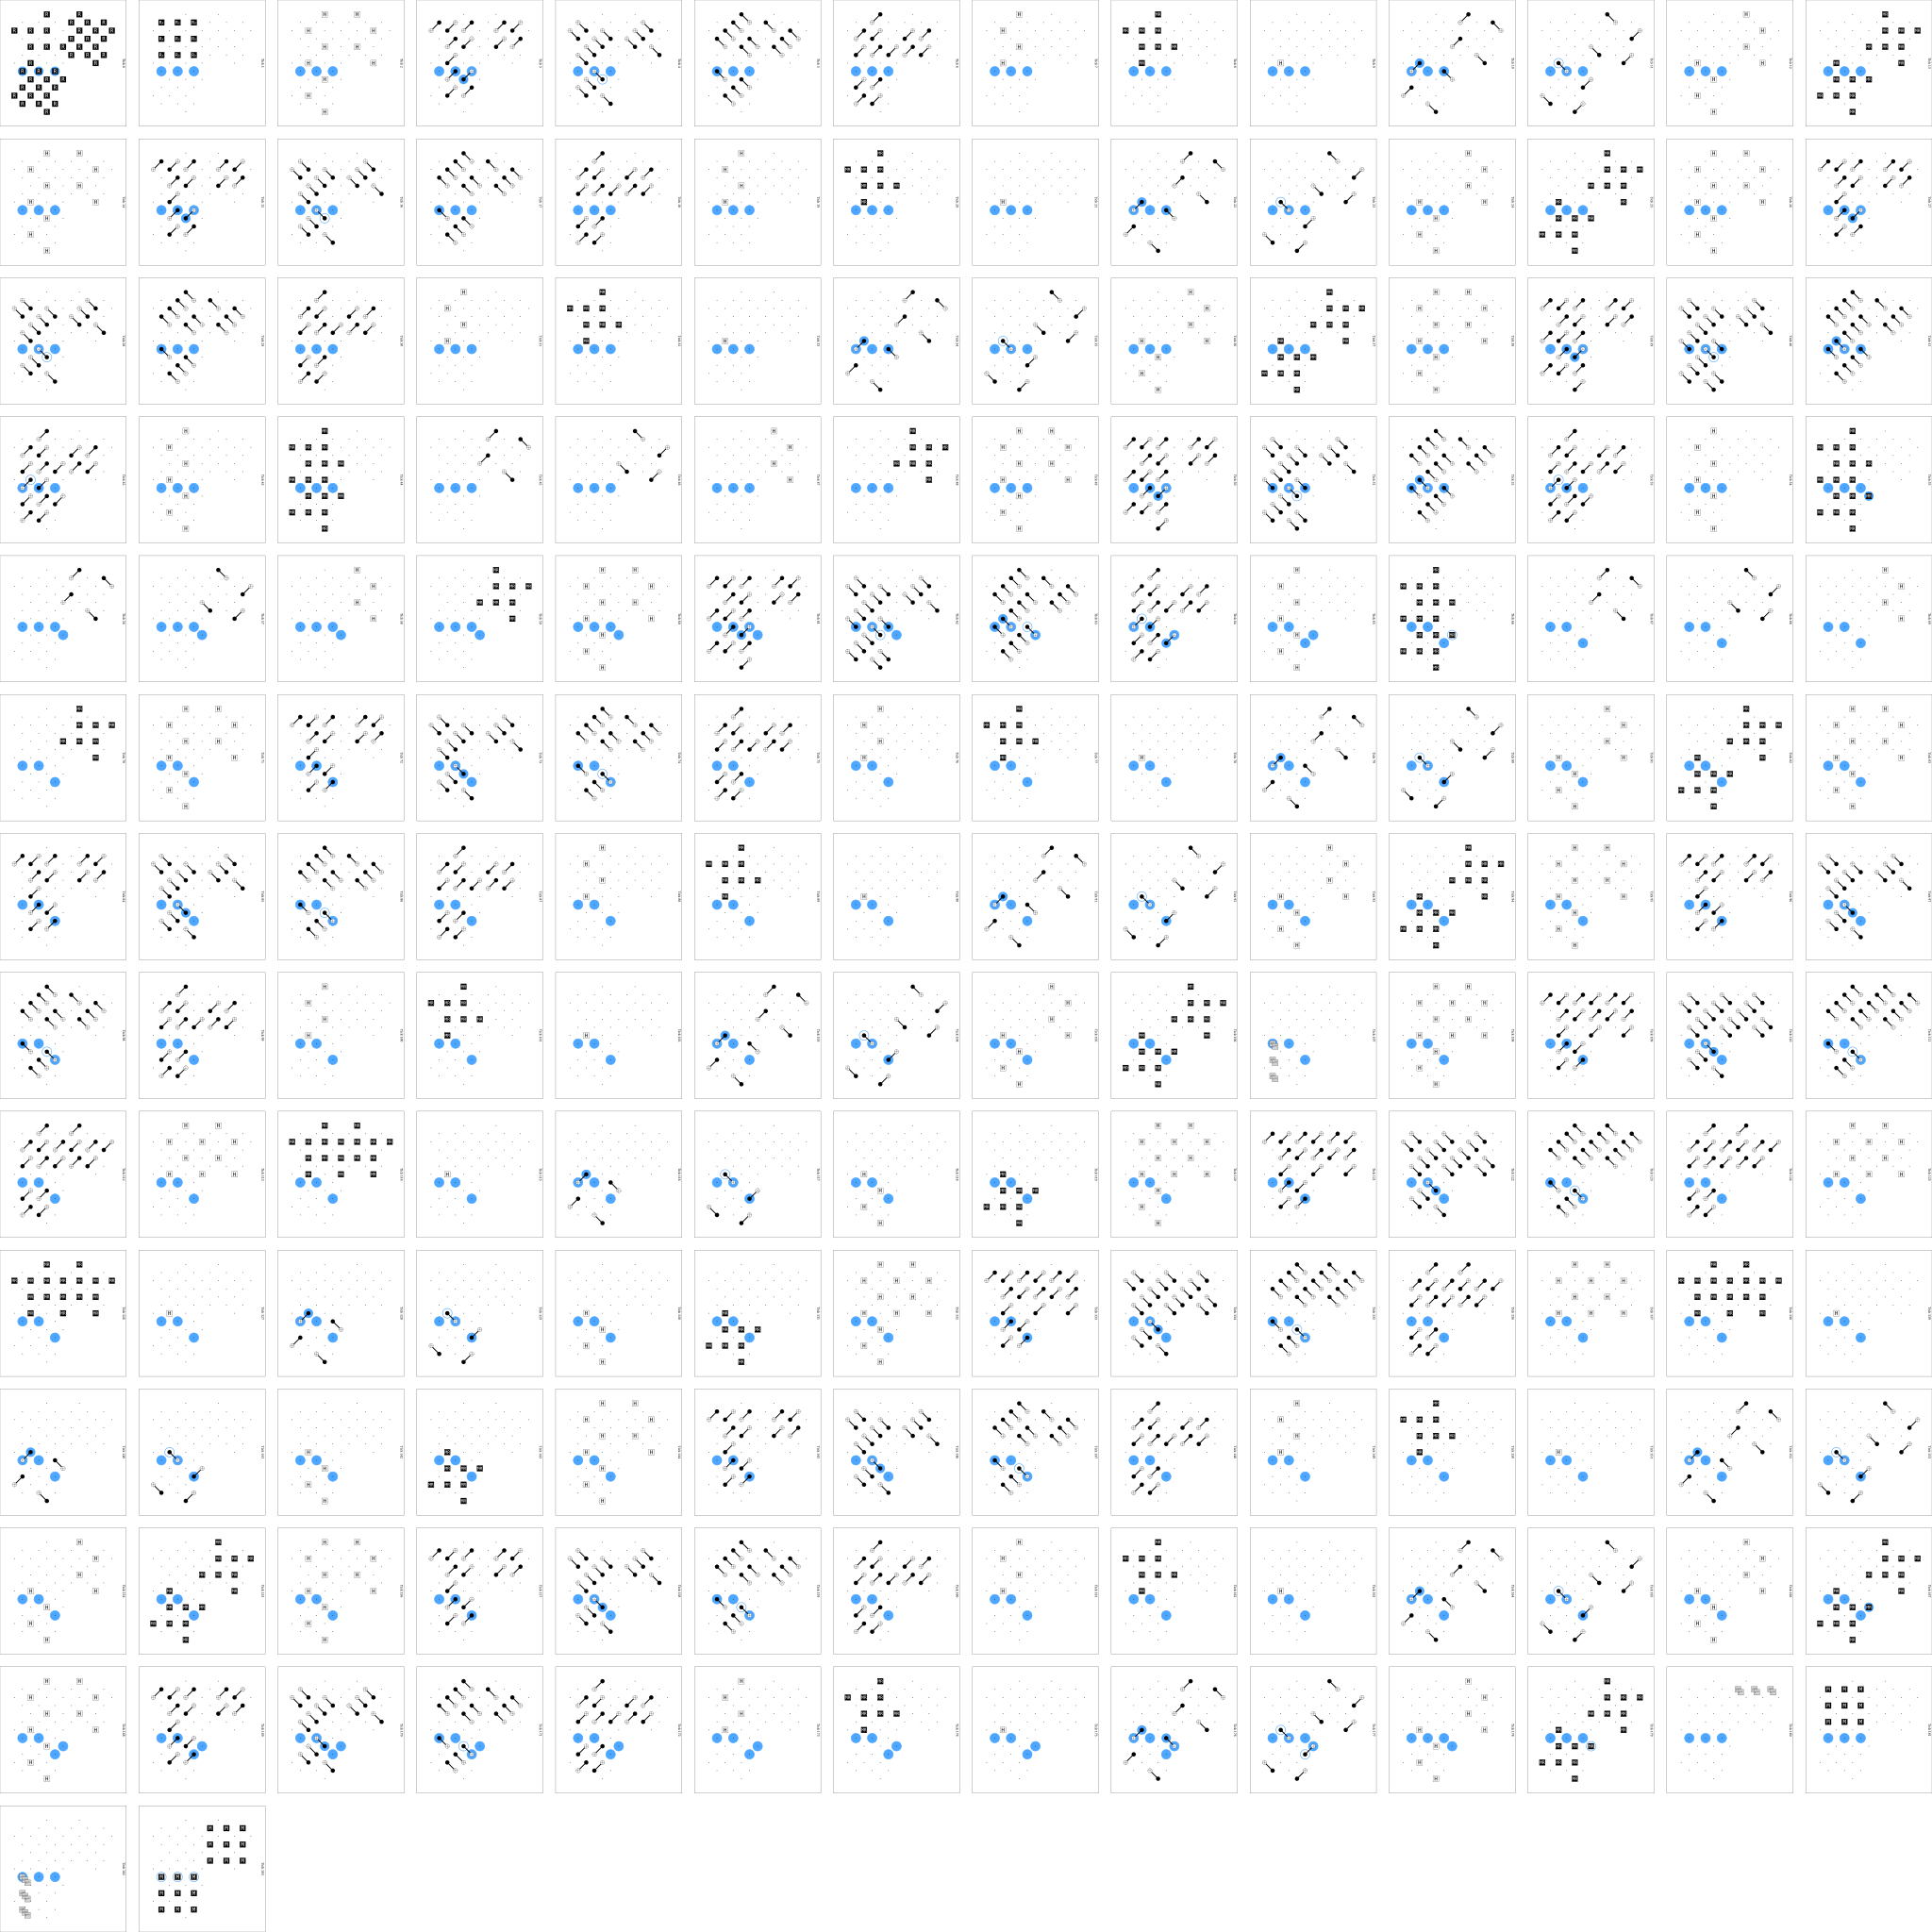

In [18]:
test_circuit = surgery_circuit(distance = 3, target_state_init="Z0", control_state_init="Z0", 
                               flow_observable = "Z -> Z")
test_circuit.diagram("detslice-with-ops-svg", filter_coords=["L0",])

In [ ]:
task_noisy_XX = [sinter.Task(
    circuit = surgery_circuit(
        distance = d, 
        target_state_init ="X+", 
        control_state_init ="X+",
        flow_observable = "X -> XX",
        noise_after_clifford_depol = noise,
        noise_measure_flip = noise,
        noise_after_reset = noise,
        noise_depol_data_init = noise
        ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.010, 0.015, 0.1, 0.125, 0.2, 0.25, 0.3, 0.4, 0.5]
    for d in [3,5,7]
    ]

stats_noisy_XX : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_XX,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=10000,
    print_progress=True
)

In [ ]:

task_noisy_X = [sinter.Task(
    circuit = surgery_circuit(
        distance = d, 
        target_state_init ="X+", 
        control_state_init ="X+",
        flow_observable = "X -> X",
        noise_after_clifford_depol = noise,
        noise_measure_flip = noise,
        noise_after_reset = noise,
        noise_depol_data_init = noise
        ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.010, 0.015, 0.1, 0.125, 0.2, 0.25, 0.3, 0.4, 0.5]
    for d in [3,5,7]
    ]


stats_noisy_X : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_X,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=10000,
    print_progress=True
)

In [ ]:
task_noisy_Z = [sinter.Task(
    circuit = surgery_circuit(
        distance = d, 
        target_state_init ="Z0", 
        control_state_init ="Z0",
        flow_observable = "Z -> Z",
        noise_after_clifford_depol = noise,
        noise_measure_flip = noise,
        noise_after_reset = noise,
        noise_depol_data_init = noise
        ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.010, 0.015, 0.1, 0.125, 0.2, 0.25, 0.3, 0.4, 0.5]
    for d in [3,5,7]
    ]


stats_noisy_Z : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_Z,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=10000,
    print_progress=True
)

In [ ]:
task_noisy_ZZ = [sinter.Task(
    circuit = surgery_circuit(
        distance = d, 
        target_state_init ="Z0", 
        control_state_init ="Z0",
        flow_observable = "Z -> ZZ",
        noise_after_clifford_depol = noise,
        noise_measure_flip = noise,
        noise_after_reset = noise,
        noise_depol_data_init = noise
        ),
    json_metadata={'p': noise, 'distance' : d}
    ) 
    for noise in [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.010, 0.015, 0.1, 0.125, 0.2, 0.25, 0.3, 0.4, 0.5]
    for d in [3,5,7]
    ]


stats_noisy_ZZ : list[sinter.TaskStats] = sinter.collect(
    num_workers = os.cpu_count(),
    tasks=task_noisy_ZZ,
    decoders=['pymatching'],
    max_shots=100_000_0,
    max_errors=10000,
    print_progress=True
)

In [ ]:
#Dumping Stats with pickle:
with open("Pckl Data/LCSX/lattice_surgery_measurement_noise_full_Z.pkl", "wb") as file:
    pickle.dump(stats_noisy_Z, file)

In [ ]:
#Dumping Stats with pickle:
with open("Pckl Data/LCSX/lattice_surgery_measurement_noise_full_ZZ.pkl", "wb") as file:
    pickle.dump(stats_noisy_ZZ, file)

In [ ]:
#Dumping Stats with pickle:
with open("Pckl Data/LCSX/lattice_surgery_measurement_noise_full_XX.pkl", "wb") as file:
    pickle.dump(stats_noisy_XX, file)

In [ ]:
with open("Pckl Data/LCSX/lattice_surgery_measurement_noise_full_X.pkl", "wb") as file:
    pickle.dump(stats_noisy_X, file)

In [ ]:
#Loading Stats with pickle
with open("Pckl Data/LCSX/lattice_surgery_measurement_noise_full_X.pkl", "rb") as file:
    stats_noisy_X = pickle.load(file)

In [ ]:
#Loading Stats with pickle
with open("Pckl Data/LCSX/lattice_surgery_measurement_noise_full_XX.pkl", "rb") as file:
    stats_noisy_XX = pickle.load(file)

In [ ]:
#Loading Stats with pickle
with open("Pckl Data/LCSX/lattice_surgery_measurement_noise_full_Z.pkl", "rb") as file:
    stats_noisy_Z = pickle.load(file)

In [ ]:
#Loading Stats with pickle
with open("Pckl Data/LCSX/lattice_surgery_measurement_noise_full_ZZ.pkl", "rb") as file:
    stats_noisy_ZZ = pickle.load(file)

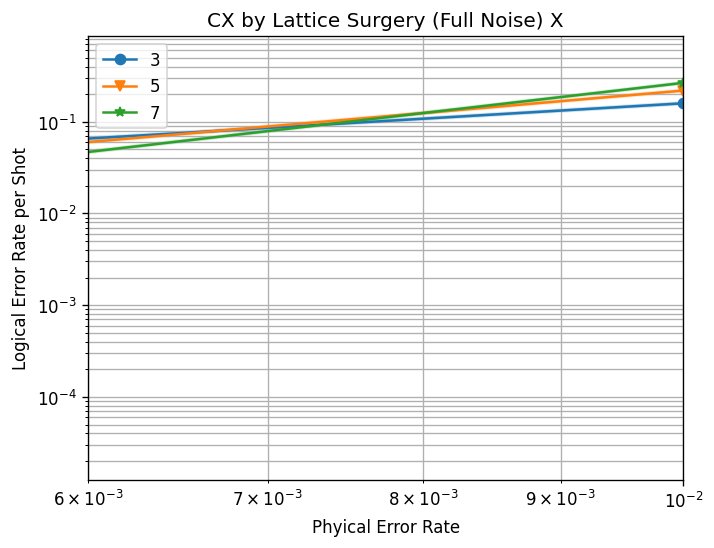

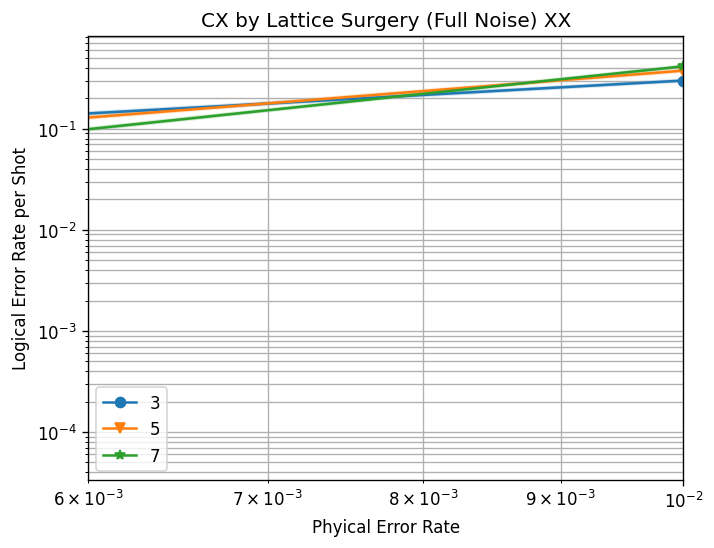

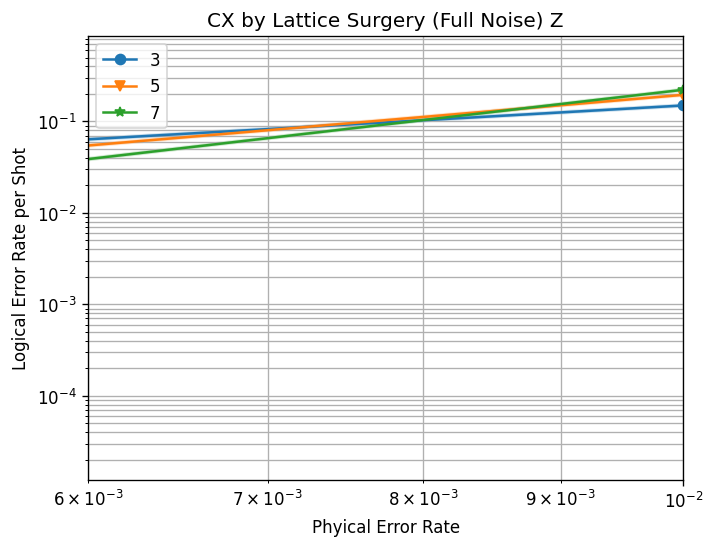

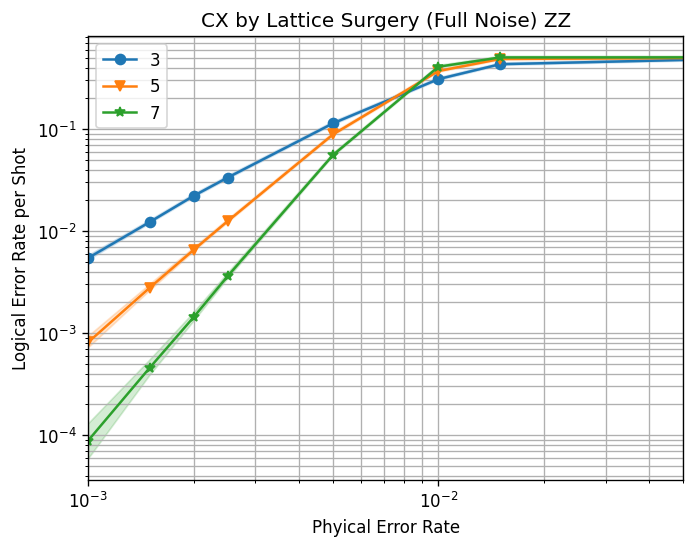

In [306]:
##################
# Plotting X Noise
##################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy_X,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(0.006, 0.01)
ax.set_title("CX by Lattice Surgery (Full Noise) X")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

###################
# Plotting XX Noise
###################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy_XX,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(0.006, 0.01)
ax.set_title("CX by Lattice Surgery (Full Noise) XX")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

###################
# Plotting Z Noise
###################

fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy_Z,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(0.006, 0.01)
ax.set_title("CX by Lattice Surgery (Full Noise) Z")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

####################
# Plotting ZZ Noise
####################


fig, ax = plt.subplots(1,1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats_noisy_ZZ,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['distance'])
ax.loglog()
ax.set_xlim(0.001, 0.05)
ax.set_title("CX by Lattice Surgery (Full Noise) ZZ")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger


In [ ]:
# Fit function: Linear
def line(p_log, a, b):
    return a * p_log + b

In [ ]:
#################################
# Calculating numerical threshold
#################################

def threshold_linear(data_stats : list[sinter.TaskStats]) -> float:

    # Creating Array for saving Data
    fitted_curves : dict = {}

    # Calculating Distances
    distances = [stat.json_metadata["distance"] for stat in data_stats]
    x_dots = []
    y_dots = []

    # Retreiving log and phys p for each Distance
    for dist in distances:
        physical_p = [stat.json_metadata["p"] for stat in data_stats if stat.json_metadata["distance"] == dist and 0.0025 < stat.json_metadata["p"] < 0.015]
        logical_p = [stat.errors / stat.shots for stat in data_stats if stat.json_metadata["distance"] == dist and 0.0025 < stat.json_metadata["p"] < 0.015]
        
        # Sort Data
        data = sorted(zip(physical_p, logical_p), key=lambda x: x[0])
        physical_p, logical_p = zip(*data)

        x_dots.append(physical_p)
        y_dots.append(logical_p)

        params, covariance = curve_fit(line, physical_p, logical_p)

        fitted_curves[dist] = params

    return fitted_curves, x_dots, y_dots


C:\Users\f.spreemann\AppData\Local\Temp\ipykernel_6644\294000859.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(line, physical_p, logical_p)


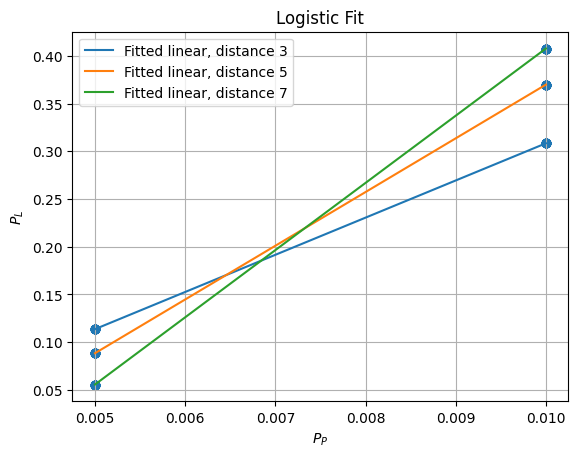

In [ ]:
lin_space = np.linspace(0.005, 0.01, 500)

values = threshold_linear(stats_noisy_ZZ)

a, b = values[0][3]
y_fit = line(lin_space, a, b)
plt.plot(lin_space, y_fit, label='Fitted linear, distance 3')
a, b = values[0][5]
y_fit = line(lin_space, a, b)
plt.plot(lin_space, y_fit, label='Fitted linear, distance 5')
a, b = values[0][7]
y_fit = line(lin_space, a, b)
plt.plot(lin_space, y_fit, label='Fitted linear, distance 7')
plt.scatter(values[1], values[2])

# Settings
plt.legend()
plt.xlabel('$P_P$')
plt.ylabel('$P_L$')
plt.title('Logistic Fit')
plt.grid(which='major')
plt.grid(which='minor')
plt.grid(True)
plt.show()

In [ ]:
def sigmoid_model(p_phys, p_th, a, d):
    return 1 / (1 + np.exp(-a * (p_phys - p_th) * d))

In [417]:
def crossing_point(params1, d1, params2, d2, p_min=0.001, p_max=0.01):
    def diff(p):
        return sigmoid_model(p, *params1, d1) - sigmoid_model(p, *params2, d2)
    
    # Check that function changes sign
    if np.sign(diff(p_min)) == np.sign(diff(p_max)):
        raise ValueError("The sigmoid curves do not cross in the given interval.")
    
    return brentq(diff, p_min, p_max)

In [418]:
#################################
# Calculating numerical threshold
#################################

def threshold_sigma(data_stats : list[sinter.TaskStats]) -> float:

    # Creating Array for saving Data
    fitted_curves : dict = {}

    # Calculating Distances
    distances = [stat.json_metadata["distance"] for stat in data_stats]
    x_dots = []
    y_dots = []

    # Retreiving log and phys p for each Distance
    for dist in distances:
        physical_p = [stat.json_metadata["p"] for stat in data_stats if stat.json_metadata["distance"] == dist and stat.json_metadata["p"] < 0.1]
        logical_p = [stat.errors / stat.shots for stat in data_stats if stat.json_metadata["distance"] == dist and stat.json_metadata["p"] < 0.1]
        
        # Sort Data
        data = sorted(zip(physical_p, logical_p), key=lambda x: x[0])
        physical_p, logical_p = zip(*data)

        x_dots.append(physical_p)
        y_dots.append(logical_p)

        model = lambda p_phys, p_th, a: sigmoid_model(p_phys, p_th, a, dist)
        params, covariance = curve_fit(model, physical_p, logical_p, p0=[0.01, 1000], bounds=([6e-4, 1e-2], [0.02, 1e4]))

        fitted_curves[dist] = params
        """
        for d, (p_th, a) in fitted_curves.items():
            print(f"d = {d}: p_th = {p_th:.6f}, a = {a:.2f}")
        """
        
    p_cross = crossing_point(fitted_curves[5], 5, fitted_curves[7], 7)
    print(f"Estimated threshold from crossing d=5 & d=7: {p_cross:.6f}")

